In [1]:
import pandas as pd
df = pd.read_csv("restaurant.csv")
df.head(1)

,Restaurant_ID,Restaurant_Name,Country_Code,City,Address,Locality,Locality_Verbose,Longitude,Latitude,Cuisines,...,Currency,Has_Table_booking,Has_Online_delivery,Is_delivering_now,Switch_to_order_menu,Price_range,Aggregate_rating,Rating_color,Rating_text,Votes
0,16608483,DiVine,14,Penola,"39 Church St, Penola, SA",Penola,"Penola, Penola",140.837409,-37.379153,"Cafe, Coffee and Tea, Sandwich",...,Dollar($),0,0,0,No,2,3.4,Orange,average,19


In [3]:
!pip install scikit-learn

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ---------------------------------------- 61.0/61.0 kB 1.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB 9.6 MB/s eta 0:00:01
   --- ------------------------------------ 0.8/8.0 MB 9.8 MB/s eta 0:00:01
   ------- -------------------------------- 1.4/8.0 MB 11.5 MB/s eta 0:00:01
   ----------- ---------------------------- 2.4/8.0 MB 13.8 MB/s eta 0:00:01
   ----------------- ---------------------- 3.6/8.0 MB 16.4 MB/s eta 0:00:01
   --------------------------- ------------ 5.4/8.0 MB 20.4 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 25.4 MB/s eta 0:00:01
   ---------------------------------------  8.0/8.0 MB 24.4 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 21.4 MB/s eta 0:00:00
   ------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = df[[
    "Average_Cost_for_two",
    "Aggregate_rating",
    "Votes",
    "Price_range"
]].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
df.loc[features.index, "cluster"] = kmeans.fit_predict(X_scaled)

In [10]:
df[["Restaurant_Name", "cluster"]].head()

,Restaurant_Name,cluster
0,DiVine,1.0
1,Hula Grill,0.0
2,Shogun Japanese Steak House,0.0
3,Thai Paradise,0.0
4,Gallery Caf� - Hyatt Place,0.0


In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = df[[
    "Average_Cost_for_two",
    "Aggregate_rating",
    "Votes"
]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = df.groupby("cluster").agg({
    "Average_Cost_for_two": "mean",
    "Aggregate_rating": "mean",
    "Votes": "mean"
}).reset_index()

cluster_summary = cluster_summary.sort_values("Average_Cost_for_two").reset_index(drop=True)

labels = ["Budget Eats", "Popular Mid-range", "Luxury Dining"]
cluster_summary["segment"] = labels

cluster_map = dict(zip(cluster_summary["cluster"], cluster_summary["segment"]))
df["segment"] = df["cluster"].map(cluster_map)

print("Cluster Summary:")
print(cluster_summary)

print("\nSample Output:")
df[["Restaurant_Name", "Average_Cost_for_two", "Aggregate_rating", "segment"]].head(10)

Cluster Summary:
   cluster  Average_Cost_for_two  Aggregate_rating       Votes  \
0        2            340.281920          0.000000    0.870923   
1        0            911.702659          3.438266  202.047748   
2        1         444444.444444          4.255556  627.222222   

             segment  
0        Budget Eats  
1  Popular Mid-range  
2      Luxury Dining  

Sample Output:


,Restaurant_Name,Average_Cost_for_two,Aggregate_rating,segment
0,DiVine,20.0,3.4,Popular Mid-range
1,Hula Grill,40.0,4.3,Popular Mid-range
2,Shogun Japanese Steak House,40.0,3.5,Popular Mid-range
3,Thai Paradise,25.0,3.7,Popular Mid-range
4,Gallery Caf� - Hyatt Place,1500.0,3.8,Popular Mid-range
5,Italia Cafe by Aura,400.0,2.8,Popular Mid-range
6,Burger Point,300.0,3.8,Popular Mid-range
7,Hyderabad Spl. Chicken Biryani Point,350.0,3.0,Popular Mid-range
8,Instapizza,900.0,4.0,Popular Mid-range
9,Schezwan Bakery,200.0,0.0,Budget Eats


In [16]:
geo_df = df[["Latitude", "Longitude"]].dropna()

scaler = StandardScaler()
geo_scaled = scaler.fit_transform(geo_df)

kmeans_geo = KMeans(n_clusters=5, random_state=42)
df.loc[geo_df.index, "geo_cluster"] = kmeans_geo.fit_predict(geo_scaled)

In [17]:
df[["Latitude", "Longitude", "geo_cluster"]].head()

,Latitude,Longitude,geo_cluster
0,-37.379153,140.837409,0.0
1,20.921347,-156.693821,3.0
2,31.611800,-84.223300,3.0
3,42.861871,-112.450106,3.0
4,28.500898,77.065948,1.0


In [20]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

geo_df = df[["Latitude", "Longitude"]].dropna()

scaler = StandardScaler()
geo_scaled = scaler.fit_transform(geo_df)

k = 10  
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(geo_scaled)

df.loc[geo_df.index, "geo_cluster"] = clusters

cluster_density = df.groupby("geo_cluster").size().reset_index(name="restaurant_count")

top_hubs = cluster_density.sort_values("restaurant_count", ascending=False).head(5)

cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=["Latitude", "Longitude"]
)

top_hubs = top_hubs.merge(
    cluster_centers.reset_index().rename(columns={"index": "geo_cluster"}),
    on="geo_cluster"
)

print("Top High-Competition Food Hubs:")
print(top_hubs)

print("\nSample Restaurant Mapping:")
df[["Restaurant_Name", "Latitude", "Longitude", "geo_cluster"]].head()

Top High-Competition Food Hubs:
   geo_cluster  restaurant_count   Latitude     Longitude
0          1.0              7736  28.567092  7.726712e+01
1          4.0               495   0.000000 -2.700062e-13
2          5.0               342  21.801798  7.214247e+01
3          7.0               257  31.089170 -8.939891e+01
4          9.0               188  12.066174  8.262586e+01

Sample Restaurant Mapping:


,Restaurant_Name,Latitude,Longitude,geo_cluster
0,DiVine,-37.379153,140.837409,3.0
1,Hula Grill,20.921347,-156.693821,7.0
2,Shogun Japanese Steak House,31.611800,-84.223300,7.0
3,Thai Paradise,42.861871,-112.450106,2.0
4,Gallery Caf� - Hyatt Place,28.500898,77.065948,1.0


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import OneHotEncoder

features = df[[
    "Average_Cost_for_two",
    "Aggregate_rating",
    "Votes",
    "Has_Table_booking",
    "Has_Online_delivery"
]].copy()

features = features.dropna()

target = df.loc[features.index, "Price_range"]

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))

importance = pd.DataFrame({
    "feature": features.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nFeature Importance:\n", importance)

results = X_test.copy()
results["Actual"] = y_test
results["Predicted"] = predictions

print("\nSample Predictions:")
results.head()

Accuracy: 0.9386149003147953

Classification Report:
               precision    recall  f1-score   support

           1       0.96      0.99      0.97       876
           2       0.95      0.95      0.95       628
           3       0.86      0.89      0.88       277
           4       0.84      0.68      0.75       125

    accuracy                           0.94      1906
   macro avg       0.91      0.88      0.89      1906
weighted avg       0.94      0.94      0.94      1906


Feature Importance:
                 feature  importance
0  Average_Cost_for_two    0.740326
2                 Votes    0.122078
1      Aggregate_rating    0.074035
3     Has_Table_booking    0.047424
4   Has_Online_delivery    0.016137

Sample Predictions:


,Average_Cost_for_two,Aggregate_rating,Votes,Has_Table_booking,Has_Online_delivery,Actual,Predicted
1087,150.0,0.0,1,0,0,1,1
6308,500.0,3.7,78,0,1,2,2
8021,550.0,3.5,90,0,0,2,2
9483,10.0,4.2,943,0,0,1,1
4459,600.0,3.0,11,0,1,2,2


In [23]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df["Cuisines"] = df["Cuisines"].fillna("Unknown")

tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(df["Cuisines"])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

def recommend(restaurant_name, top_n=5):
    
    idx_list = df[df["Restaurant_Name"] == restaurant_name].index.tolist()
    
    if not idx_list:
        return "Restaurant not found"
    
    idx = idx_list[0]
    
    city = df.loc[idx, "City"]
    
    scores = list(enumerate(cosine_sim[idx]))
    
    scores = [
        (i, score) for i, score in scores
        if df.loc[i, "City"] == city and i != idx
    ]
    
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    
    top_indices = [i[0] for i in scores[:top_n]]
    return df.loc[top_indices, ["Restaurant_Name", "Cuisines", "City"]]

print(recommend("Truffles"))

     Restaurant_Name Cuisines     City
99   Cakes & Muffins   Bakery  Gurgaon
110  The Oven Artist   Bakery  Gurgaon
131     Divine Bites   Bakery  Gurgaon
381          Begonia   Bakery  Gurgaon
689         Frontier   Bakery  Gurgaon


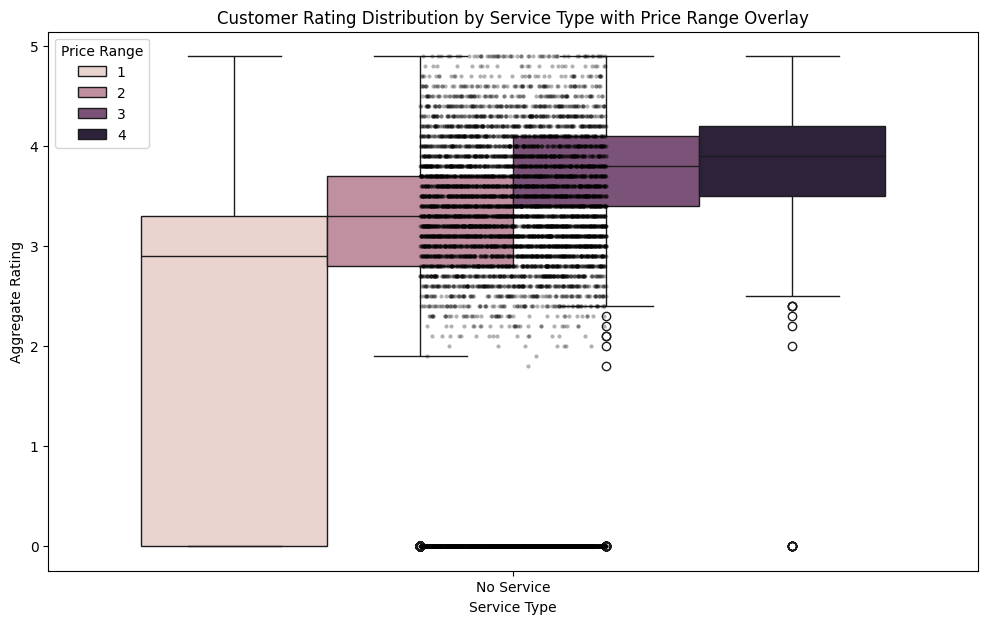

In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df["service_type"] = np.where(
    df["Has_Table_booking"] == "Yes", "Table Booking",
    np.where(df["Has_Online_delivery"] == "Yes", "Online Delivery", "No Service")
)

plot_df = df.dropna(subset=["Aggregate_rating", "Price_range"])

plt.figure(figsize=(12, 7))

sns.boxplot(
    x="service_type",
    y="Aggregate_rating",
    hue="Price_range",
    data=plot_df
)

sns.stripplot(
    x="service_type",
    y="Aggregate_rating",
    data=plot_df,
    color="black",
    alpha=0.3,
    jitter=True,
    size=3
)

plt.title("Customer Rating Distribution by Service Type with Price Range Overlay")
plt.xlabel("Service Type")
plt.ylabel("Aggregate Rating")

plt.legend(title="Price Range")
plt.show()